In [1]:
# !pip install xgboost lightgbm missingno

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/data')

train_data_path = join(data_dir, 'train.csv')
sub_data_path = join(data_dir, 'test.csv')

print(train_data_path)
print(sub_data_path)

/home/jovyan/work/kaggle_kakr_housing/data/train.csv
/home/jovyan/work/kaggle_kakr_housing/data/test.csv


## 1. 데이터 살펴보기
pandas의 read_csv 함수를 사용해 데이터를 읽어오고, 각 변수들이 나타내는 의미를 살펴보겠습니다.
1. ID : 집을 구분하는 번호
2. date : 집을 구매한 날짜
3. price : 타겟 변수인 집의 가격
4. bedrooms : 침실의 수
5. bathrooms : 침실당 화장실 개수
6. sqft_living : 주거 공간의 평방 피트
7. sqft_lot : 부지의 평방 피트
8. floors : 집의 층 수
9. waterfront : 집의 전방에 강이 흐르는지 유무 (a.k.a. 리버뷰)
10. view : 집이 얼마나 좋아 보이는지의 정도
11. condition : 집의 전반적인 상태
12. grade : King County grading 시스템 기준으로 매긴 집의 등급
13. sqft_above : 지하실을 제외한 평방 피트
14. sqft_basement : 지하실의 평방 피트
15. yr_built : 집을 지은 년도
16. yr_renovated : 집을 재건축한 년도
17. zipcode : 우편번호
18. lat : 위도
19. long : 경도
20. sqft_living15 : 2015년 기준 주거 공간의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음), 가장 가까운 15가구의 주택 내부 생활 공간 면적?
21. sqft_lot15 : 2015년 기준 부지의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음), 가장 가까운 15가구의 토지 면적(제곱피트)?

In [5]:
data = pd.read_csv(train_data_path)
sub = pd.read_csv(sub_data_path)
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (15035, 21)
sub data dim : (6468, 20)


In [6]:
y = data['price']

del data['price']

print(data.columns)

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [7]:
#pd.concat: 모델 학습 전, 전체 데이터 탑색 위해 두 데이터 합침!
train_len = len(data) #추후 다시 데이터 분리 용이하도록 인덱스 저장
data = pd.concat((data, sub), axis=0) #axis=0은 기존 데이터 아래 새로운 데이터를 '행'으로 추가

In [8]:
data.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


## 2. 전처리 
각 변수들에 대해 결측 유무를 확인하고, 분포를 확인해보면서 간단하게 전처리를 하겠습니다.
### 결측치 확인
먼저 데이터에 결측치가 있는지를 확인하겠습니다.<br>
missingno 라이브러리의 matrix 함수를 사용하면, 데이터의 결측 상태를 시각화를 통해 살펴볼 수 있습니다.

<Axes: >

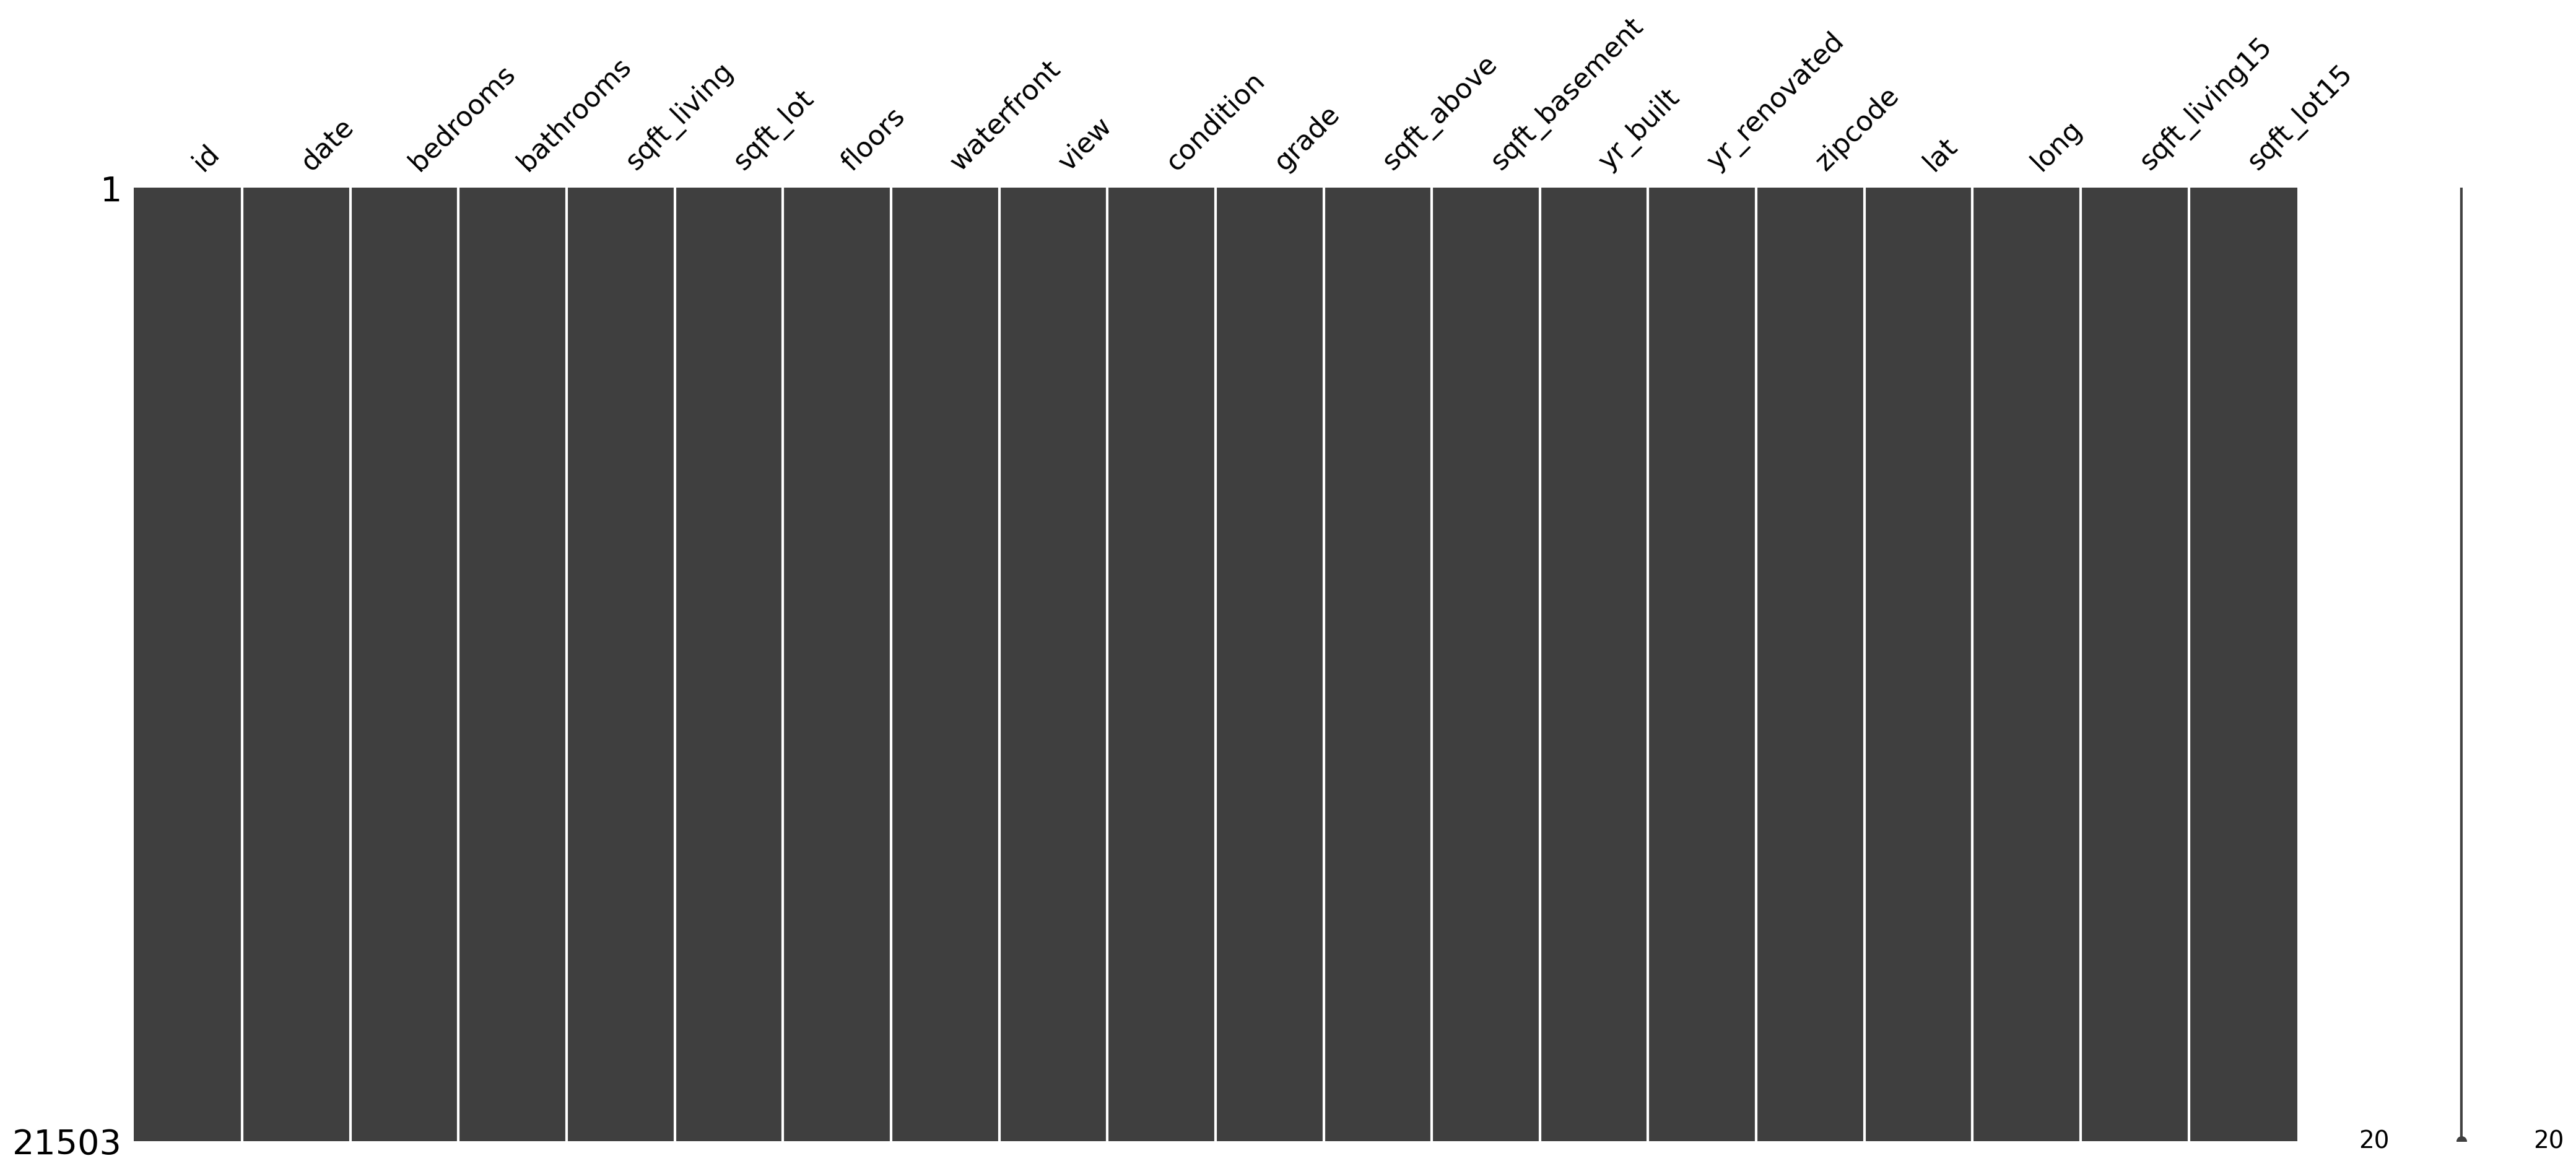

In [9]:
msno.matrix(data)

모든 변수에 결측치가 없는 것으로 보이지만, 혹시 모르니 확실하게 살펴보겠습니다.<br>

In [10]:
#모든 컬럼에 대해 결측치 유무 확인
for c in data.columns:
    print('{} : {}'.format(c, len(data.loc[pd.isnull(data[c]), c].values)))

id : 0
date : 0
bedrooms : 0
bathrooms : 0
sqft_living : 0
sqft_lot : 0
floors : 0
waterfront : 0
view : 0
condition : 0
grade : 0
sqft_above : 0
sqft_basement : 0
yr_built : 0
yr_renovated : 0
zipcode : 0
lat : 0
long : 0
sqft_living15 : 0
sqft_lot15 : 0


### id, date 변수 정리
id 변수는 모델이 집값을 예측하는데 도움을 주지 않으므로 제거합니다.<br>
date 변수는 연월일시간으로 값을 가지고 있는데, 연월만 고려하는 범주형 변수로 만들겠습니다.

In [11]:
#test 데이터 id 만 저장해두기
sub_id = data['id'][train_len:]


In [12]:
del data['id']

In [13]:
#date는 연/월로 구분하기
data['year'] = data['date'].str[:4].astype(int)
data['month'] = data['date'].str[4:6].astype(int)

print(data['year'][:5])
print(data['month'][:5])

0    2014
1    2015
2    2015
3    2014
4    2015
Name: year, dtype: int64
0    10
1     2
2     2
3     6
4     1
Name: month, dtype: int64


In [14]:
#date 컬럼 지우기
del data['date']

In [15]:
print(data.columns)
print(data.shape)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'year', 'month'],
      dtype='object')
(21503, 20)


### 각 변수들의 분포 확인(커널 밀도 추정; KDE)
한쪽으로 치우친 분포는 모델이 결과를 예측하기에 좋지 않은 영향을 미치므로 다듬어줄 필요가 있습니다. 
Kernel Density Estimation(커널 밀도 추정): 데이터가 어디에 얼마나 몰려 있는지 부드러운 곡선으로 그려주는 도구

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21503 entries, 0 to 6467
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       21503 non-null  int64  
 1   bathrooms      21503 non-null  float64
 2   sqft_living    21503 non-null  int64  
 3   sqft_lot       21503 non-null  int64  
 4   floors         21503 non-null  float64
 5   waterfront     21503 non-null  int64  
 6   view           21503 non-null  int64  
 7   condition      21503 non-null  int64  
 8   grade          21503 non-null  int64  
 9   sqft_above     21503 non-null  int64  
 10  sqft_basement  21503 non-null  int64  
 11  yr_built       21503 non-null  int64  
 12  yr_renovated   21503 non-null  int64  
 13  zipcode        21503 non-null  int64  
 14  lat            21503 non-null  float64
 15  long           21503 non-null  float64
 16  sqft_living15  21503 non-null  int64  
 17  sqft_lot15     21503 non-null  int64  
 18  year        



In [17]:
fig, ax = plt.subplots(10, 2, figsize=(20, 60))

# id 변수는 제외하고 분포를 확인합니다.
count = 0
columns = data.columns
for row in range(10):
    for col in range(2):
        sns.histplot(data[columns[count]], bins=30, kde=True, ax=ax[row][col])
        ax[row][col].set_title(columns[count], fontsize=15)
        count+=1
        if count == 20 :
            break

plt.tight_layout()
plt.show()

### 이상치 처리: 이상치로 편향된 데이터 로그화
- price, bedrooms, sqft_living, sqft_lot, sqft_above, sqft_basement 등 변수가 한쪽으로 치우친 경향을 보였습니다.<br>
- 실제로 방이 30개인 집이 있는데, 이상치 처리를 할 수 있지만.. 오타가 아닌 실제 데이터라 감안하여 log 변환하면 이상치가 데이터의 의미를 유지하면서 모델에 무리를 주지 않음.
- log-scaling을 통해 데이터 분포를 정규분포에 가깝게 만들어 보겠습니다.

In [18]:
skew_columns = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']

print(len(skew_columns))

#분포의 모양 바꾸기(이상치 처리 느낌임! 피처 범위 맞추는 scaling이 아님)
for c in skew_columns:
    data[c] = np.log1p(data[c].values)

8


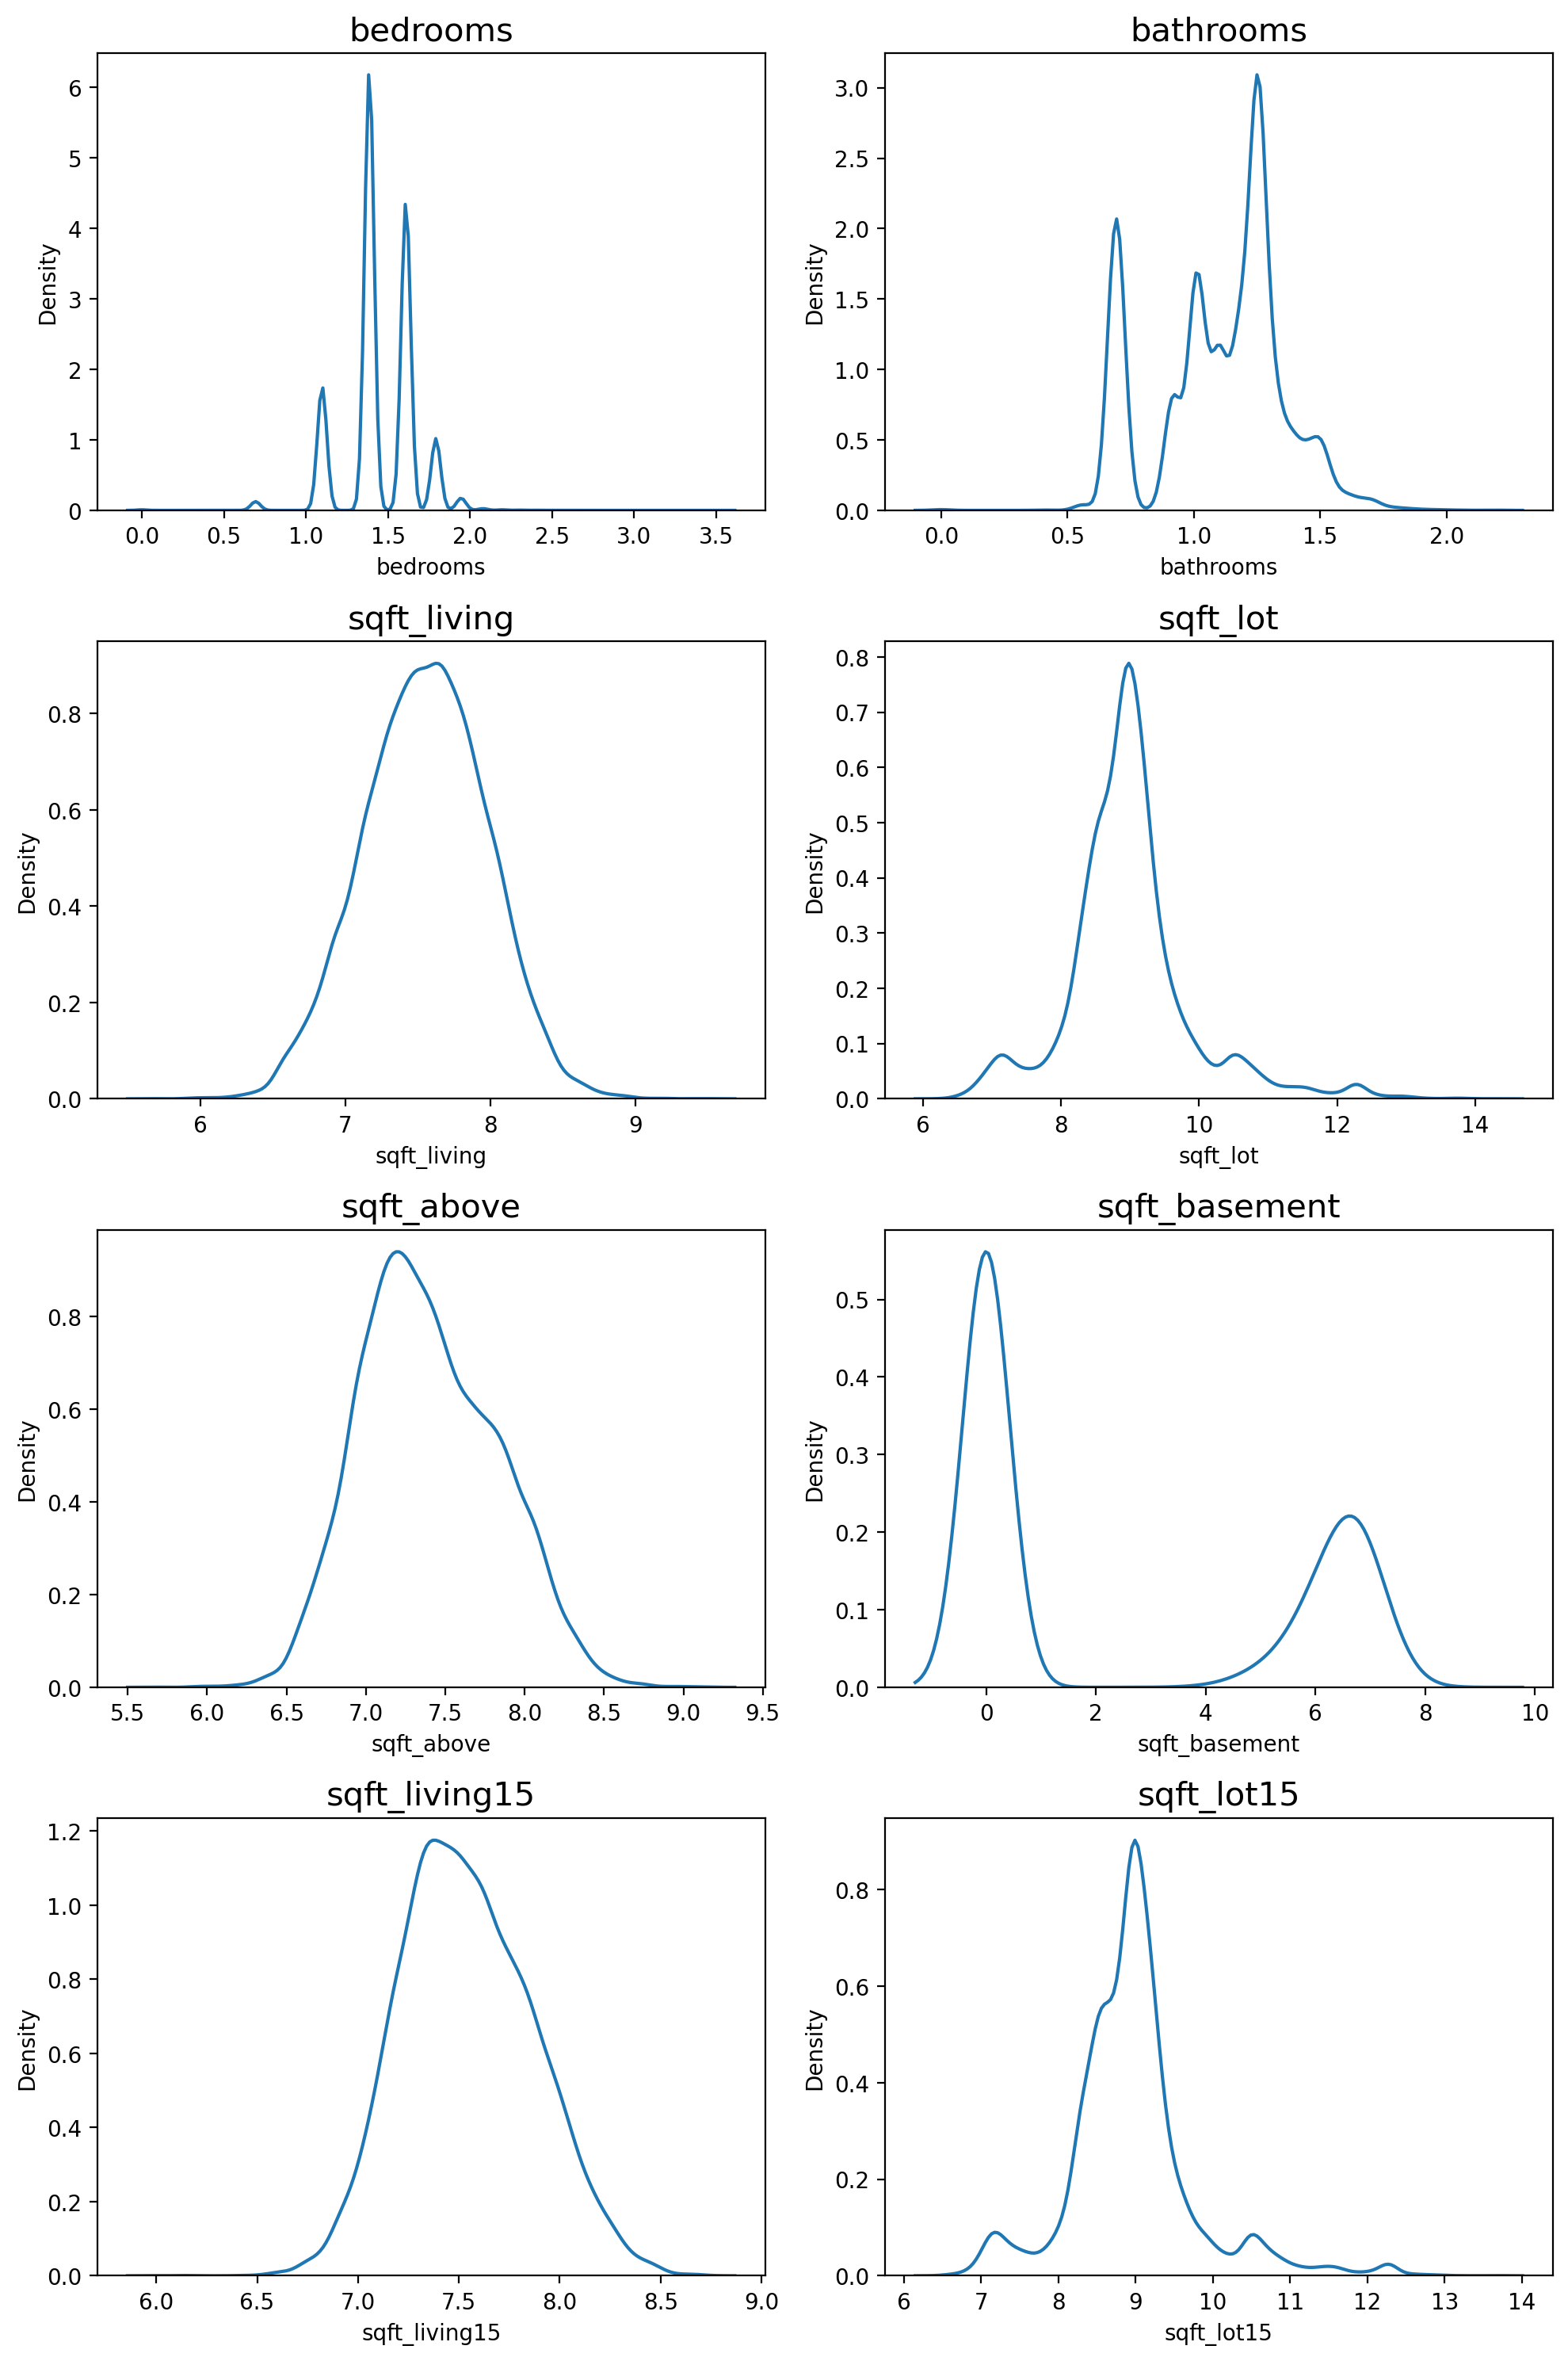

In [19]:
fig, ax = plt.subplots(4, 2, figsize=(10, 15))

count = 0
for row in range(10):
    for col in range(2):
        if count == 8:
            break
        sns.kdeplot(data[skew_columns[count]], ax=ax[row][col])
        ax[row][col].set_title(skew_columns[count], fontsize=15)
        count+=1

plt.tight_layout()
plt.show()

어느정도 치우침이 줄어든 분포를 확인할 수 있습니다.

### 타겟 데이터의 분포도 확인해보기

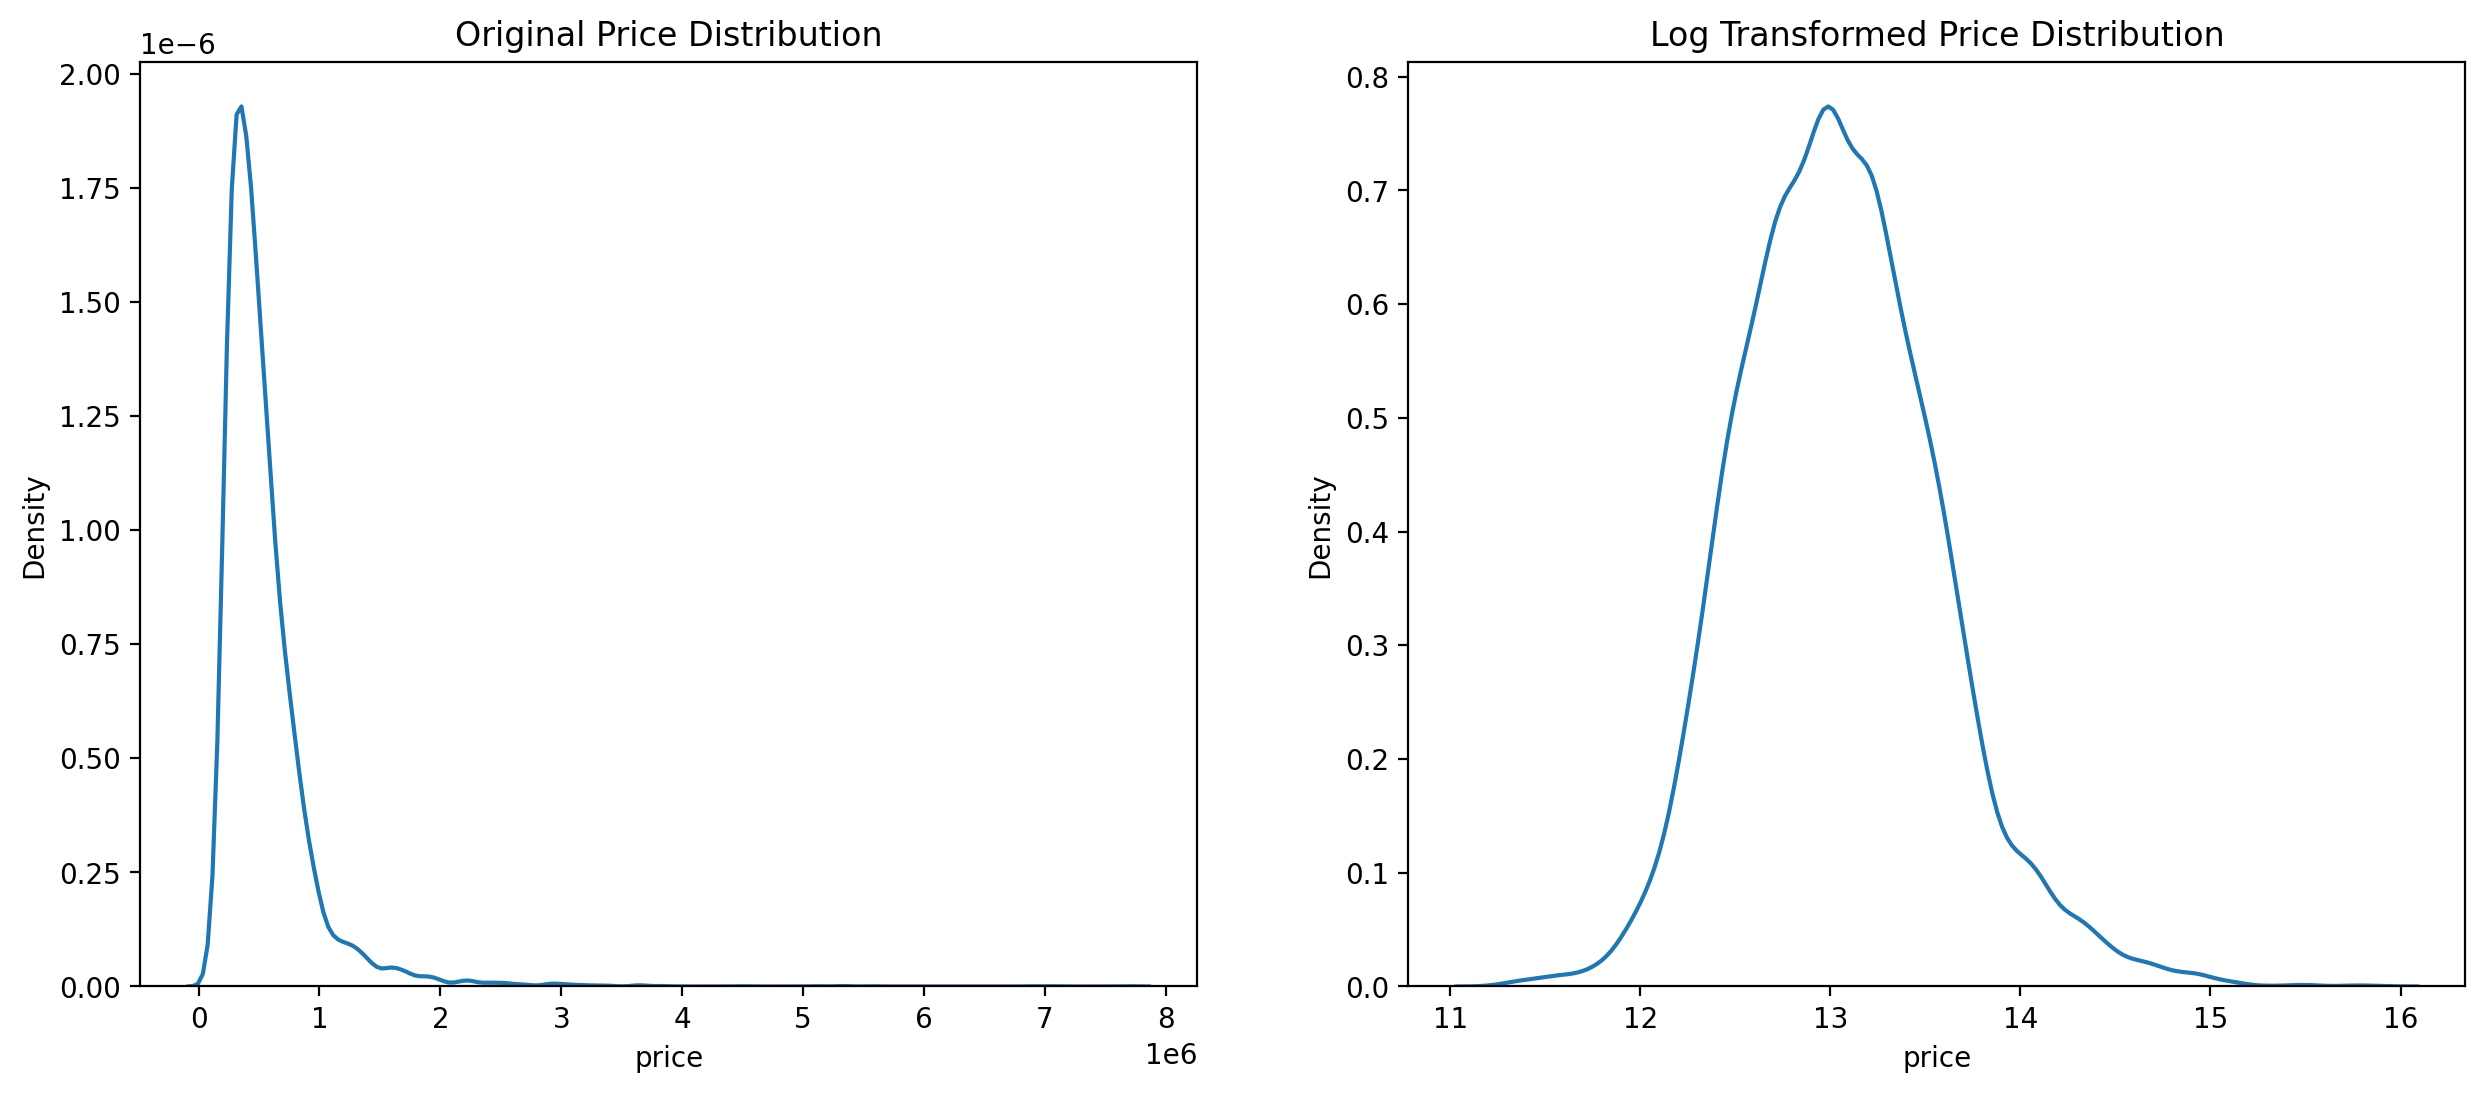

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: 변환 전 원본 데이터
sns.kdeplot(y, ax=ax[0])
ax[0].set_title('Original Price Distribution')

# 오른쪽: 로그 변환 후 데이터
sns.kdeplot(np.log1p(y), ax=ax[1])
ax[1].set_title('Log Transformed Price Distribution')

plt.show()

In [21]:
#타겟 변수도 로그변환하기
y = np.log1p(y)

## 3. Feature Selection
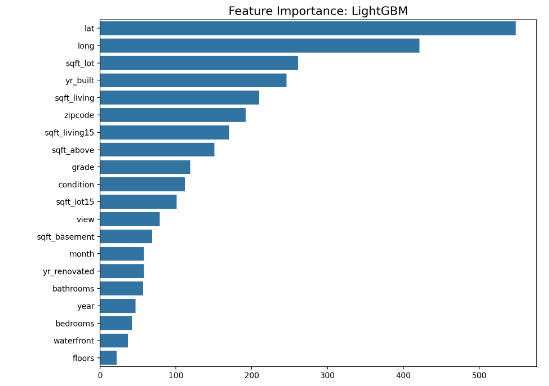
로그화만 했을 때 feature importance가 lat, long 에 과하게 치우쳐있음. 게다가 zipcode도 유사한 기능을 하는 변수임..


In [22]:
# 1. zipcode 카테고리 변수로 활용하기(aka 타겟 인코딩)

# 1. data에 임시로 y(가격)를 다시 붙여줍니다.
# 그래야 zipcode별로 가격 평균을 구할 수 있습니다.
data['temp_price'] = y

#동네별 평균 집값 리스트 만들기
#결과: 예를 들어 98103 지역의 평균가는 50만 불, 98039 지역은 200만 불 같은 식의 사전(Dictionary) 형태 데이터가 만들어짐
zipcode_price_map = data.groupby('zipcode')['temp_price'].mean()

#우편번호 숫자를 해당 동네의 평균 가격으로 치환
#원래 데이터에 zipcode가 98039라고 적혀 있었다면, 방금 만든 리스트를 보고 그 자리에 2000000 치
data['zipcode'] = data['zipcode'].map(zipcode_price_map)

In [23]:
del data['temp_price']

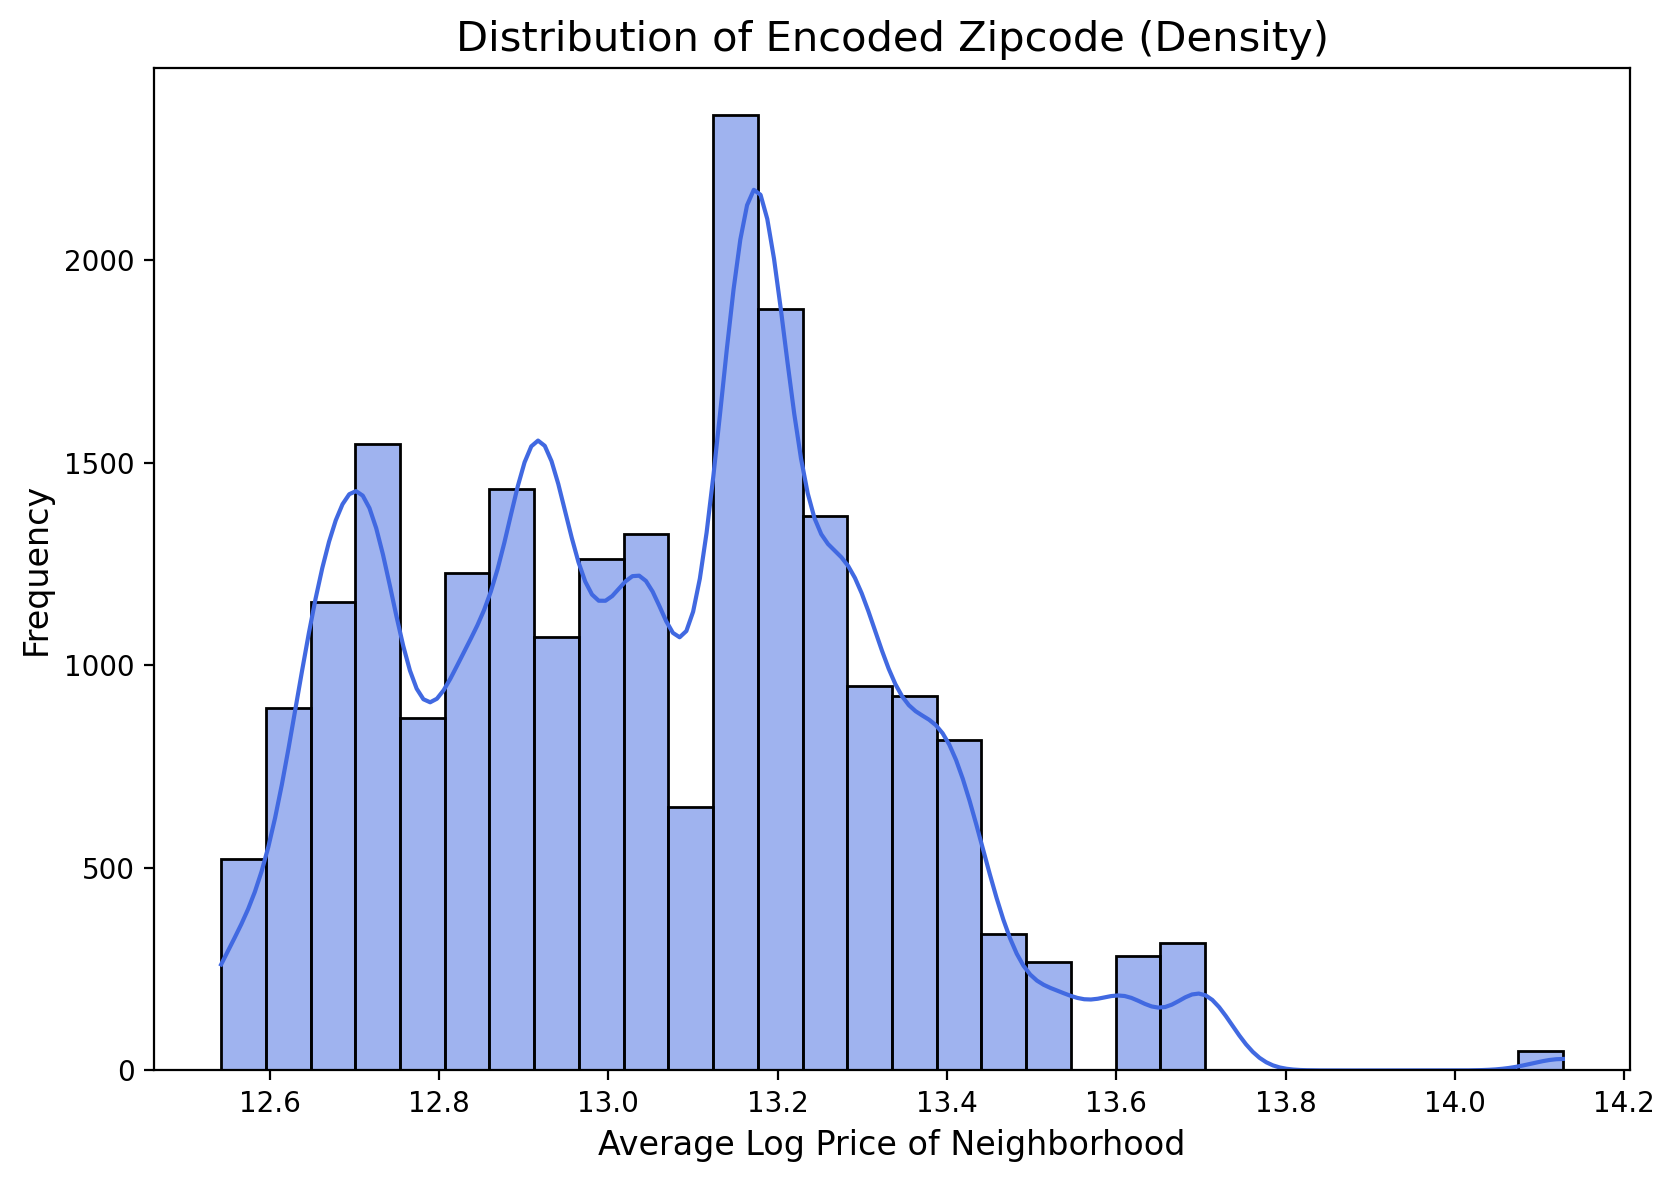

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 영역 설정 (1행 2열)
plt.figure(figsize=(16, 6))

# 1. 히스토그램 & KDE: 데이터가 어느 구간에 얼마나 집중되어 있는지 확인
plt.subplot(1, 2, 1)
sns.histplot(data['zipcode'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Encoded Zipcode (Density)', fontsize=15)
plt.xlabel('Average Log Price of Neighborhood', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

## 4. 모델링
### Average Blending
여러가지 모델의 결과를 산술 평균을 통해 Blending 모델을 만들겠습니다.

단, gboost, xgboost, lightgbm 같은 트리기반 모델은 피처 스케일링이 필요하지 않음!
'값의 크기'보다는 '값의 순서(rank)'를 사용하기 때문!
ex) "방 개수가 3개보다 큰가?" 혹은 "집값이 5억보다 큰가?"와 같이 특정 임계값을 기준으로 데이터를 분할 

그러나, 로그변환은 필요!
트리 모델은 이상치에 강한 편이지만, 너무 극단적인 값이 있으면 트리가 깊어지고 과적합(Overfitting)될 위험

In [25]:
sub = data.iloc[train_len:, :]
x = data.iloc[:train_len, :]

In [26]:
# 1. RandomizedSearchCV로 찾은 최적의 파라미터를 각 모델에 입력합니다.

# GradientBoosting: n_estimators=200, max_depth=5, learning_rate=0.1
gboost = GradientBoostingRegressor(
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=2019
)

# XGBoost: n_estimators=100, max_depth=5, learning_rate=0.1
xgboost = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=2019
)

# LightGBM: n_estimators=500, max_depth=15, learning_rate=0.05
lightgbm = lgb.LGBMRegressor(
    n_estimators=500, 
    max_depth=15, 
    learning_rate=0.05, 
    importance_type='split',
    random_state=2019,
    verbose=-1
)

# 2. 모델 리스트 구성
models = [
    {'model': gboost, 'name': 'GradientBoosting'},
    {'model': xgboost, 'name': 'XGBoost'},
    {'model': lightgbm, 'name': 'LightGBM'}
]

### 하이퍼 파라미터 튜닝(GridSearchCV, randomizedsearchCV)
예측 곡선의 Peak가 높고 Tail이 짧다는 것은 모델이 지나치게 **'평균적인 값'**만 내뱉고 있다는 아주 중요한 신호
즉, 아주 비싼 집이나 아주 싼 집의 특성을 제대로 포착하지 못하고 안전하게 중간값만 맞추려 하는 과소적합(Underfitting) 성향이 일부 보이거나, 데이터의 **변동성(Variance)**을 충분히 학습하지 못한 상태

In [27]:
# from sklearn.model_selection import RandomizedSearchCV

# #튜닝할 파라미터 범위 지정
# param_grids = {
#     'GradientBoosting': {
#         'n_estimators': [100, 200],
#         'max_depth': [5, 10],
#         'learning_rate': [0.1, 0.05]
#     },
#     'XGBoost': {
#         'n_estimators': [50, 100],
#         'max_depth': [5, 10],
#         'learning_rate': [0.1, 0.05]
#     },
#     'LightGBM': {
#         'n_estimators': [100, 500],
#         'max_depth': [10, 15],
#         'num_leaves': [31, 63],
#         'learning_rate': [0.1, 0.05]
#     }
# }

# # 랜덤 CV
# for m in models:
#     print(f"--- Tuning {m['name']} ---")
    
#     # n_iter=10: 랜덤하게 10개 조합만 뽑아서 테스트함
#     rs = RandomizedSearchCV(
#         m['model'], 
#         param_distributions=param_grids[m['name']], 
#         n_iter=10, 
#         scoring='neg_mean_squared_error', 
#         cv=3,            # CV를 3으로 낮춤
#         verbose=1, 
#         n_jobs=-1,
#         random_state=2019
#     )
    
#     rs.fit(x, y)
    
#     print(f"{m['name']} 최적 파라미터: {rs.best_params_}")
#     print(f"{m['name']} 최적 RMSE: {np.sqrt(-rs.best_score_):.4f}")
#     m['model'] = rs.best_estimator_

### Cross Validation
교차 검증을 통해 모델의 성능을 간단히 평가하겠습니다.

In [28]:
def get_cv_score(models):
    # 1. 데이터를 5개로 쪼개기 위한 규칙을 만듭니다. (5-Fold)
    # n_splits=5 는 데이터를 5묶음으로 나눈다는 뜻입니다.
    kfold = KFold(n_splits=5, random_state=2019, shuffle=True)

    for m in models:
        # 2. cross_val_score가 실제로 5번 학습/평가를 자동으로 수행합니다.
        # m['model']: 학습시킬 모델 (XGB, LGBM 등)
        # x.values, y: 학습 데이터와 타겟(로그 변환된 가격)
        # np.mean(...): 5번 나온 점수의 평균을 구합니다.
        score = np.mean(cross_val_score(m['model'], x.values, y, cv=kfold))

In [29]:
get_cv_score(models)

In [30]:
#모델 별 RMSLE 구하기

def get_rmse_score(models):
    kfold = KFold(n_splits=5, random_state=2019, shuffle=True)
    
    for m in models:
        # scoring을 MSE의 음수값으로 지정합니다.
        neg_mse_scores = cross_val_score(m['model'], x.values, y, 
                                         scoring="neg_mean_squared_error", cv=kfold)
        
        # 음수 MSE에 -를 붙여 양수로 만들고 루트를 씌워 RMSE를 계산합니다.
        rmse_scores = np.sqrt(-neg_mse_scores)
        rmse_mean = np.mean(rmse_scores)
        
        print("Model {:>10} CV RMSE     : {:.4f}".format(m['name'], rmse_mean))

In [31]:
get_rmse_score(models)

Model GradientBoosting CV RMSE     : 0.1631
Model    XGBoost CV RMSE     : 0.1665
Model   LightGBM CV RMSE     : 0.1593


### 모델 별 시각화하여 예측값 분포 보기

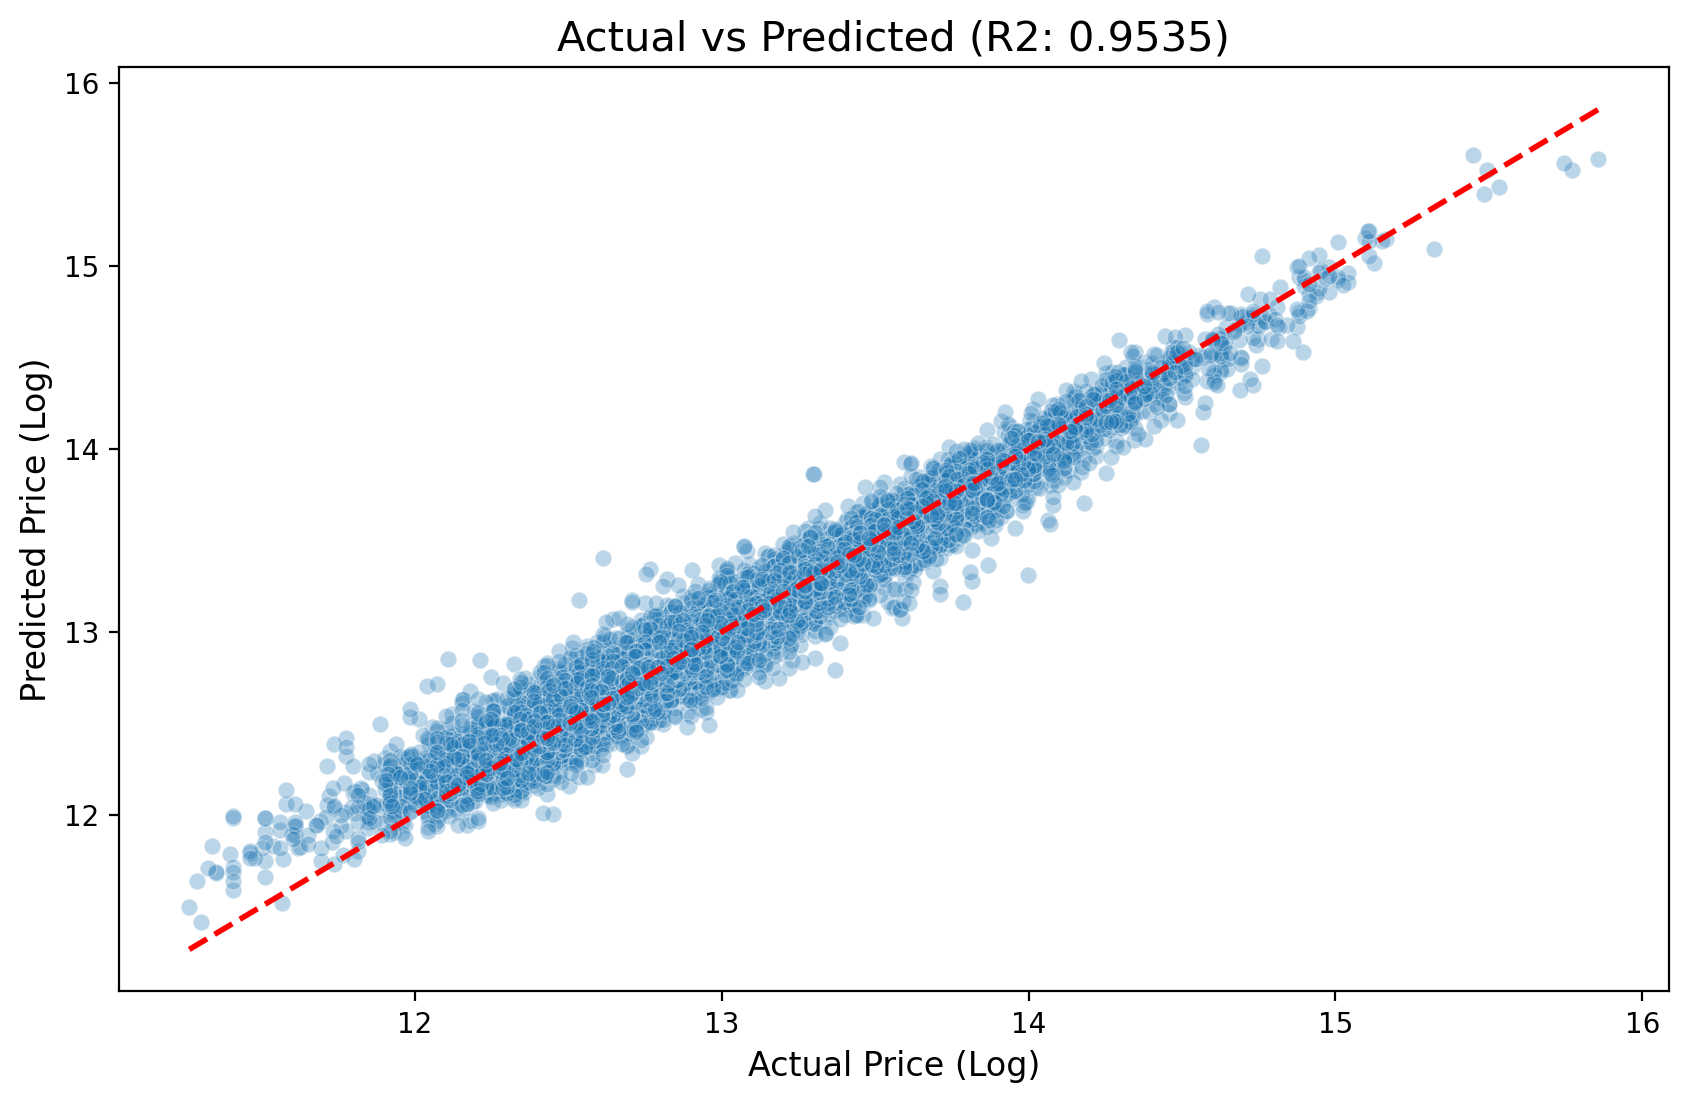

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_prediction_analysis(model, x, y):
    # 모델 학습 및 예측 (로그 단위)
    model.fit(x.values, y)
    y_pred = model.predict(x.values)
    
    plt.figure(figsize=(10, 6))
    
    # 1. 산점도 그리기
    sns.scatterplot(x=y, y=y_pred, alpha=0.3)
    
    # 2. 대각선(정답선) 그리기
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    
    plt.xlabel('Actual Price (Log)', fontsize=12)
    plt.ylabel('Predicted Price (Log)', fontsize=12)
    plt.title(f'Actual vs Predicted (R2: {model.score(x.values, y):.4f})', fontsize=15)
    plt.show()

plot_prediction_analysis(models[2]['model'], x, y)

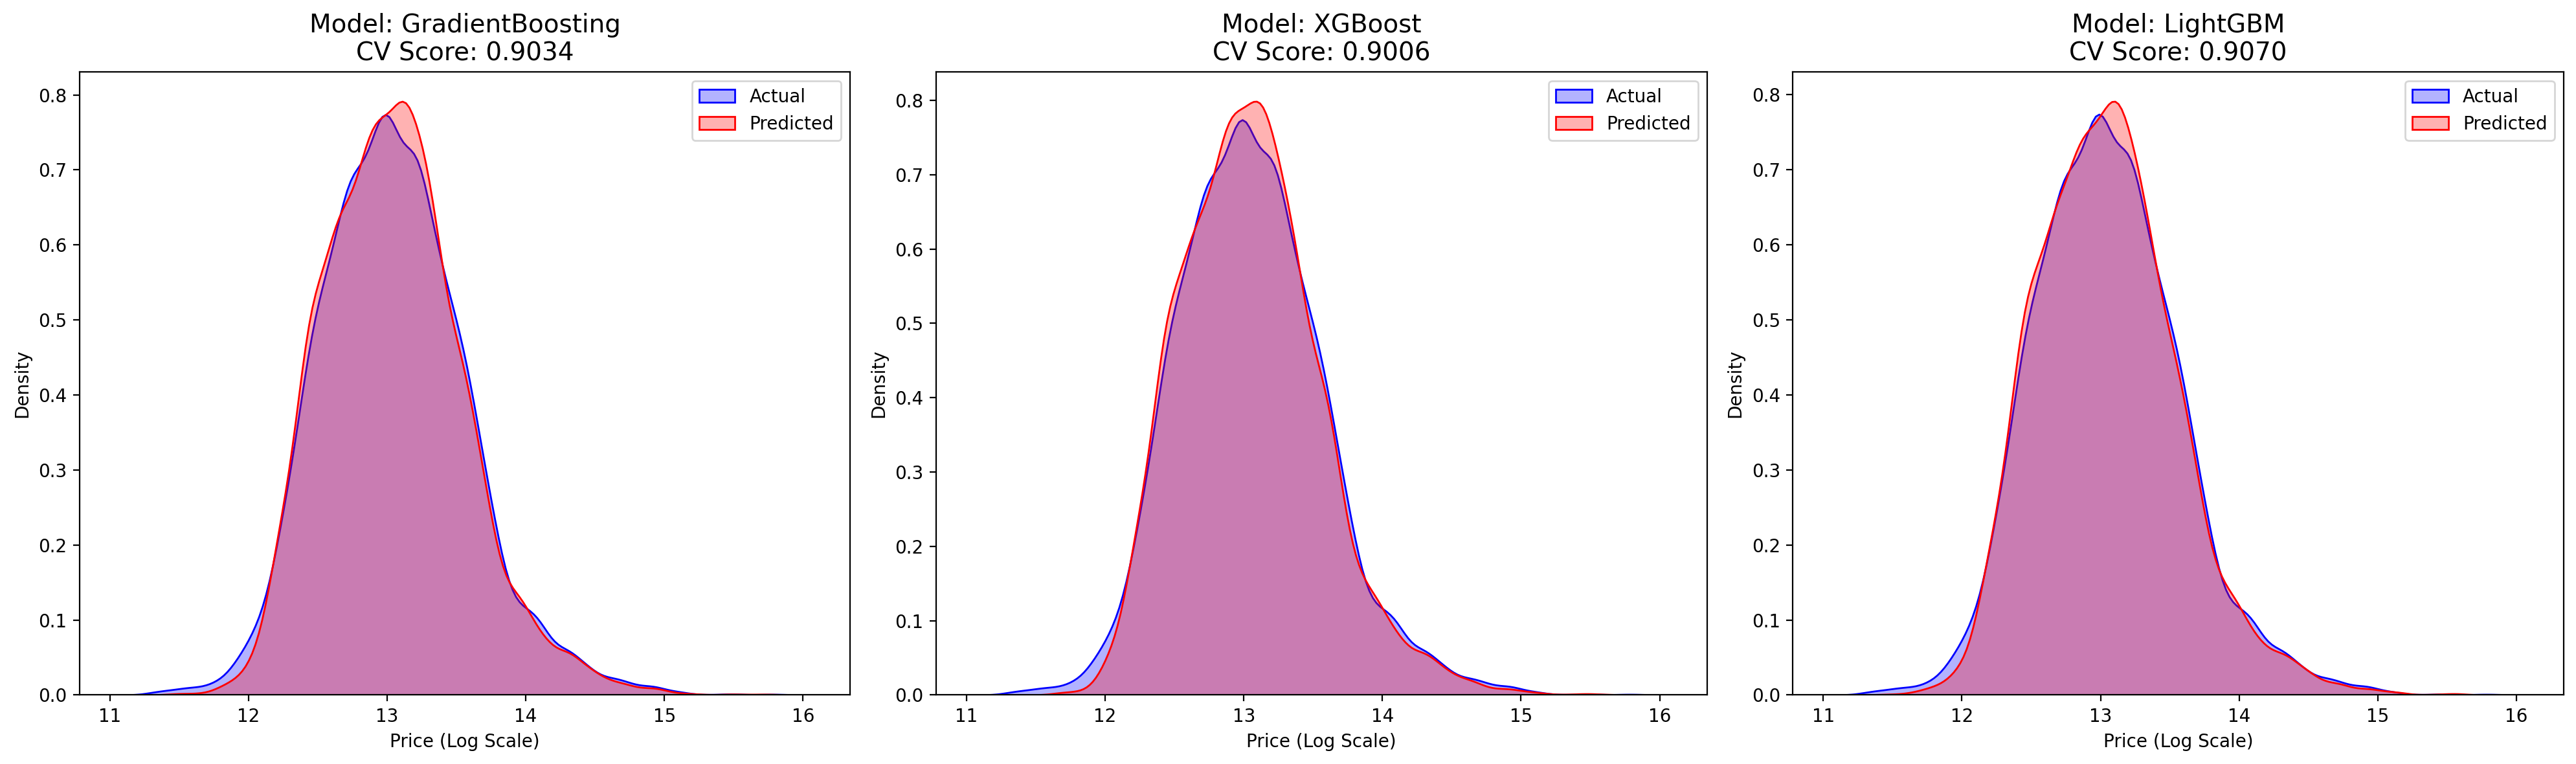

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_model_distributions(models, x, y):
    # 모델 개수에 맞춰 칸 생성 (1행 3열)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for idx, m in enumerate(models):
        # 1. 모델 학습 및 예측 (로그 단위)
        m['model'].fit(x.values, y)
        y_pred = m['model'].predict(x.values)
        
        # 2. KDE Plot 그리기
        # 실제값(y)은 파란색, 예측값(y_pred)은 빨간색
        sns.kdeplot(y, ax=axes[idx], label='Actual', fill=True, color="blue", alpha=0.3)
        sns.kdeplot(y_pred, ax=axes[idx], label='Predicted', fill=True, color="red", alpha=0.3)
        
        # 3. 그래프 꾸미기
        axes[idx].set_title(f"Model: {m['name']}\nCV Score: {np.mean(cross_val_score(m['model'], x.values, y, cv=5)):.4f}", fontsize=14)
        axes[idx].legend()
        axes[idx].set_xlabel('Price (Log Scale)')
        axes[idx].set_ylabel('Density')

    plt.tight_layout()
    plt.show()

# 함수 실행
plot_model_distributions(models, x, y)

### Make Submission

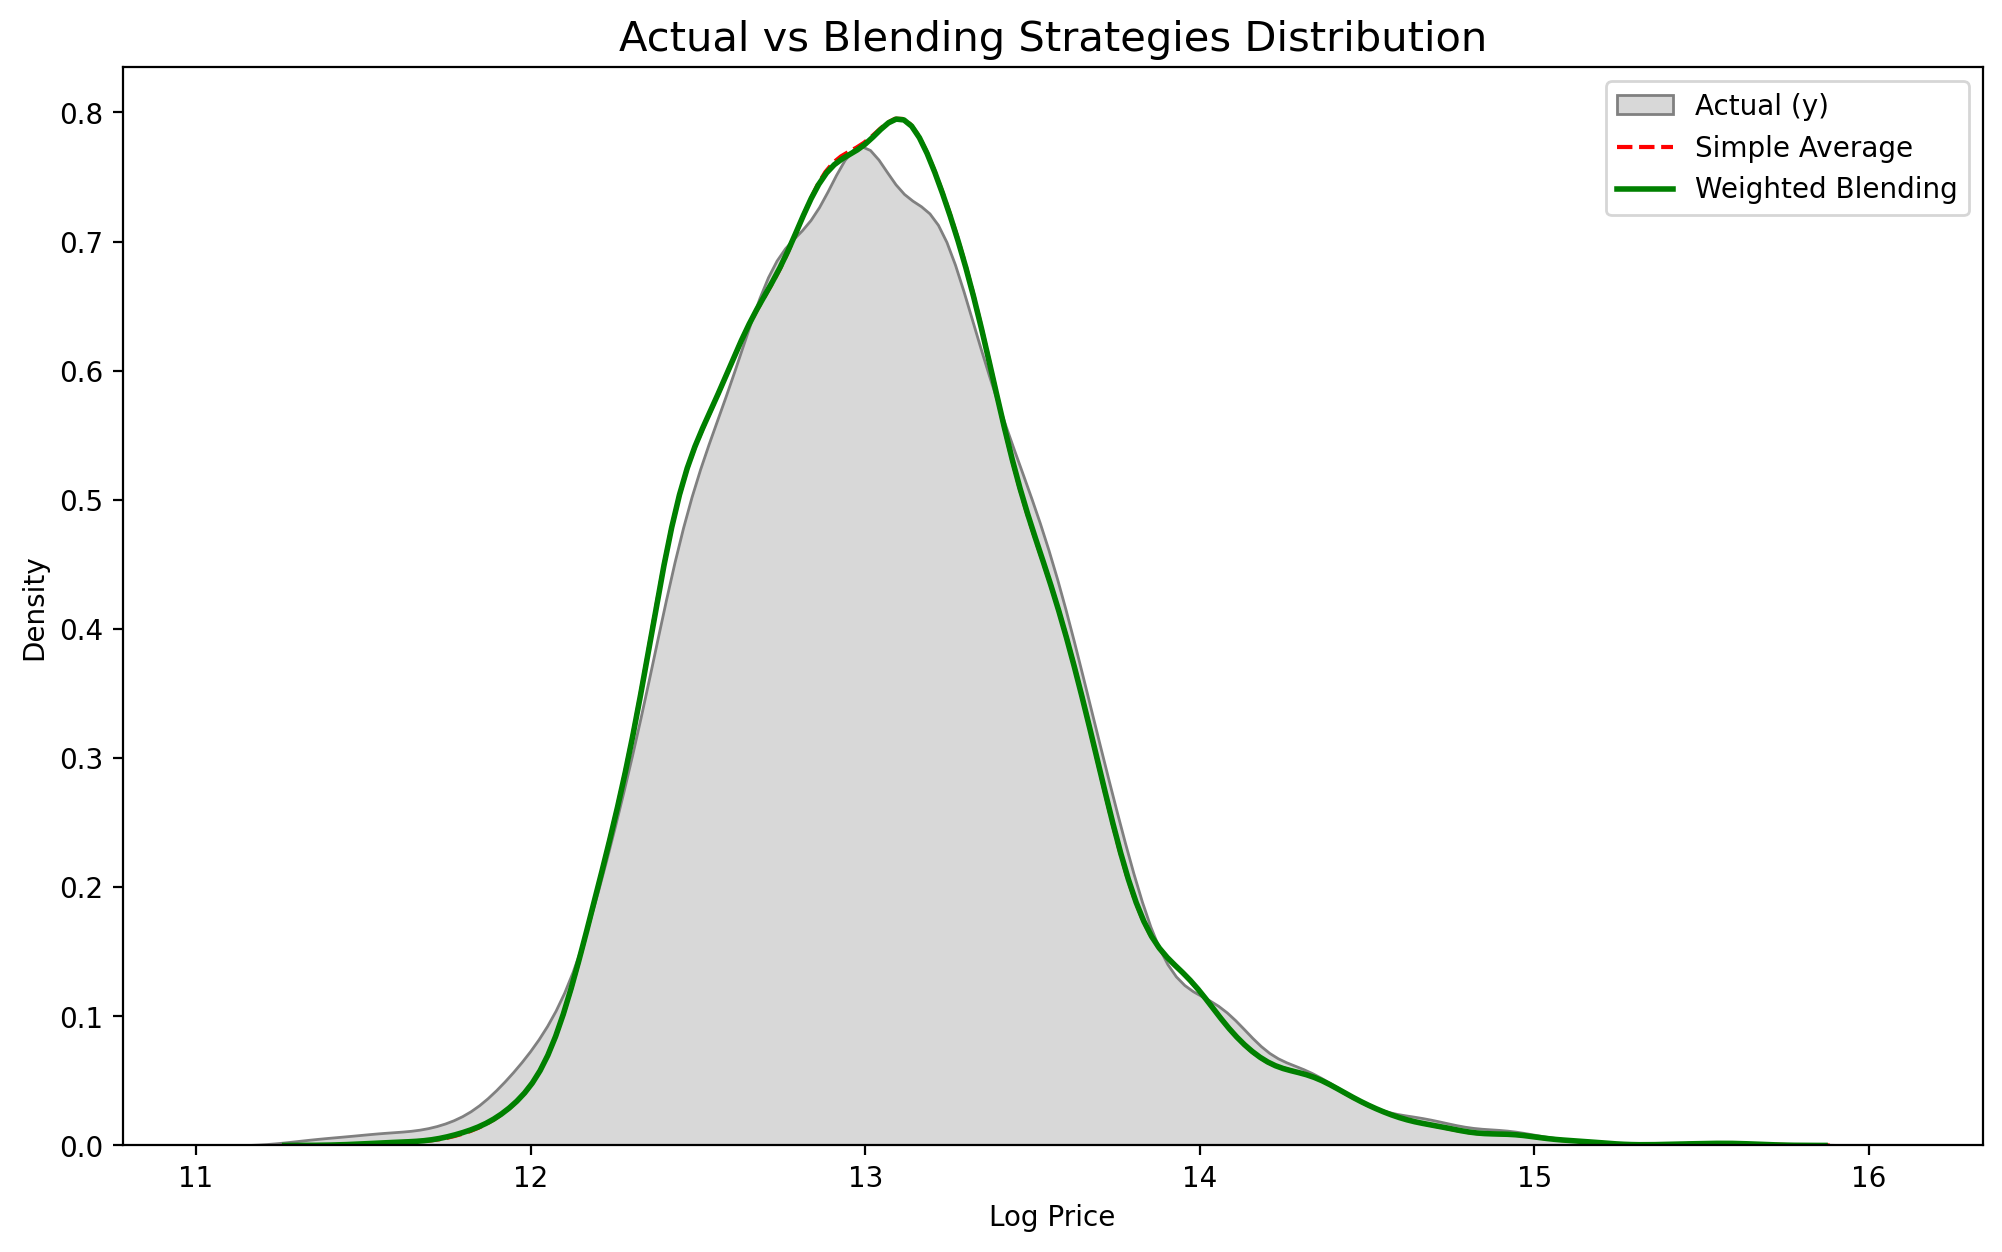

In [34]:
# 1. 가중치 설정 (성능 순: LGBM > GB > XGB)
w1, w2, w3 = 0.45, 0.30, 0.25

# 2. 각 모델의 예측값 추출 (학습 데이터 x.values 기준)
pred_gb = models[0]['model'].predict(x.values)
pred_xgb = models[1]['model'].predict(x.values)
pred_lgbm = models[2]['model'].predict(x.values)

# 3. 단순 평균 vs 가중치 블렌딩 예측값 생성
y_simple_average = (pred_gb + pred_xgb + pred_lgbm) / 3
y_weighted_blending = (w1 * pred_lgbm) + (w2 * pred_gb) + (w3 * pred_xgb)

# 4. 시각화: 실제값 vs 단순 평균 vs 가중치 블렌딩
plt.figure(figsize=(12, 7))
sns.kdeplot(y, label='Actual (y)', fill=True, color="gray", alpha=0.3)
sns.kdeplot(y_simple_average, label='Simple Average', color="red", linestyle="--")
sns.kdeplot(y_weighted_blending, label='Weighted Blending', color="green", linewidth=2)

plt.title('Actual vs Blending Strategies Distribution', fontsize=15)
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.legend()
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error

# RMSLE 계산 함수 (로그 스케일에서의 RMSE)
def get_rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 각 지표 계산
rmsle_simple = get_rmsle(y, y_simple_average)
rmsle_weighted = get_rmsle(y, y_weighted_blending)

print(f"Simple Average RMSLE   : {rmsle_simple:.4f}")
print(f"Weighted Blending RMSLE : {rmsle_weighted:.4f}")
print(f"Improvement            : {rmsle_simple - rmsle_weighted:.4f}")

Simple Average RMSLE   : 0.1253
Weighted Blending RMSLE : 0.1225
Improvement            : 0.0028


## 5. 최종모델 Feature Importance 재확인

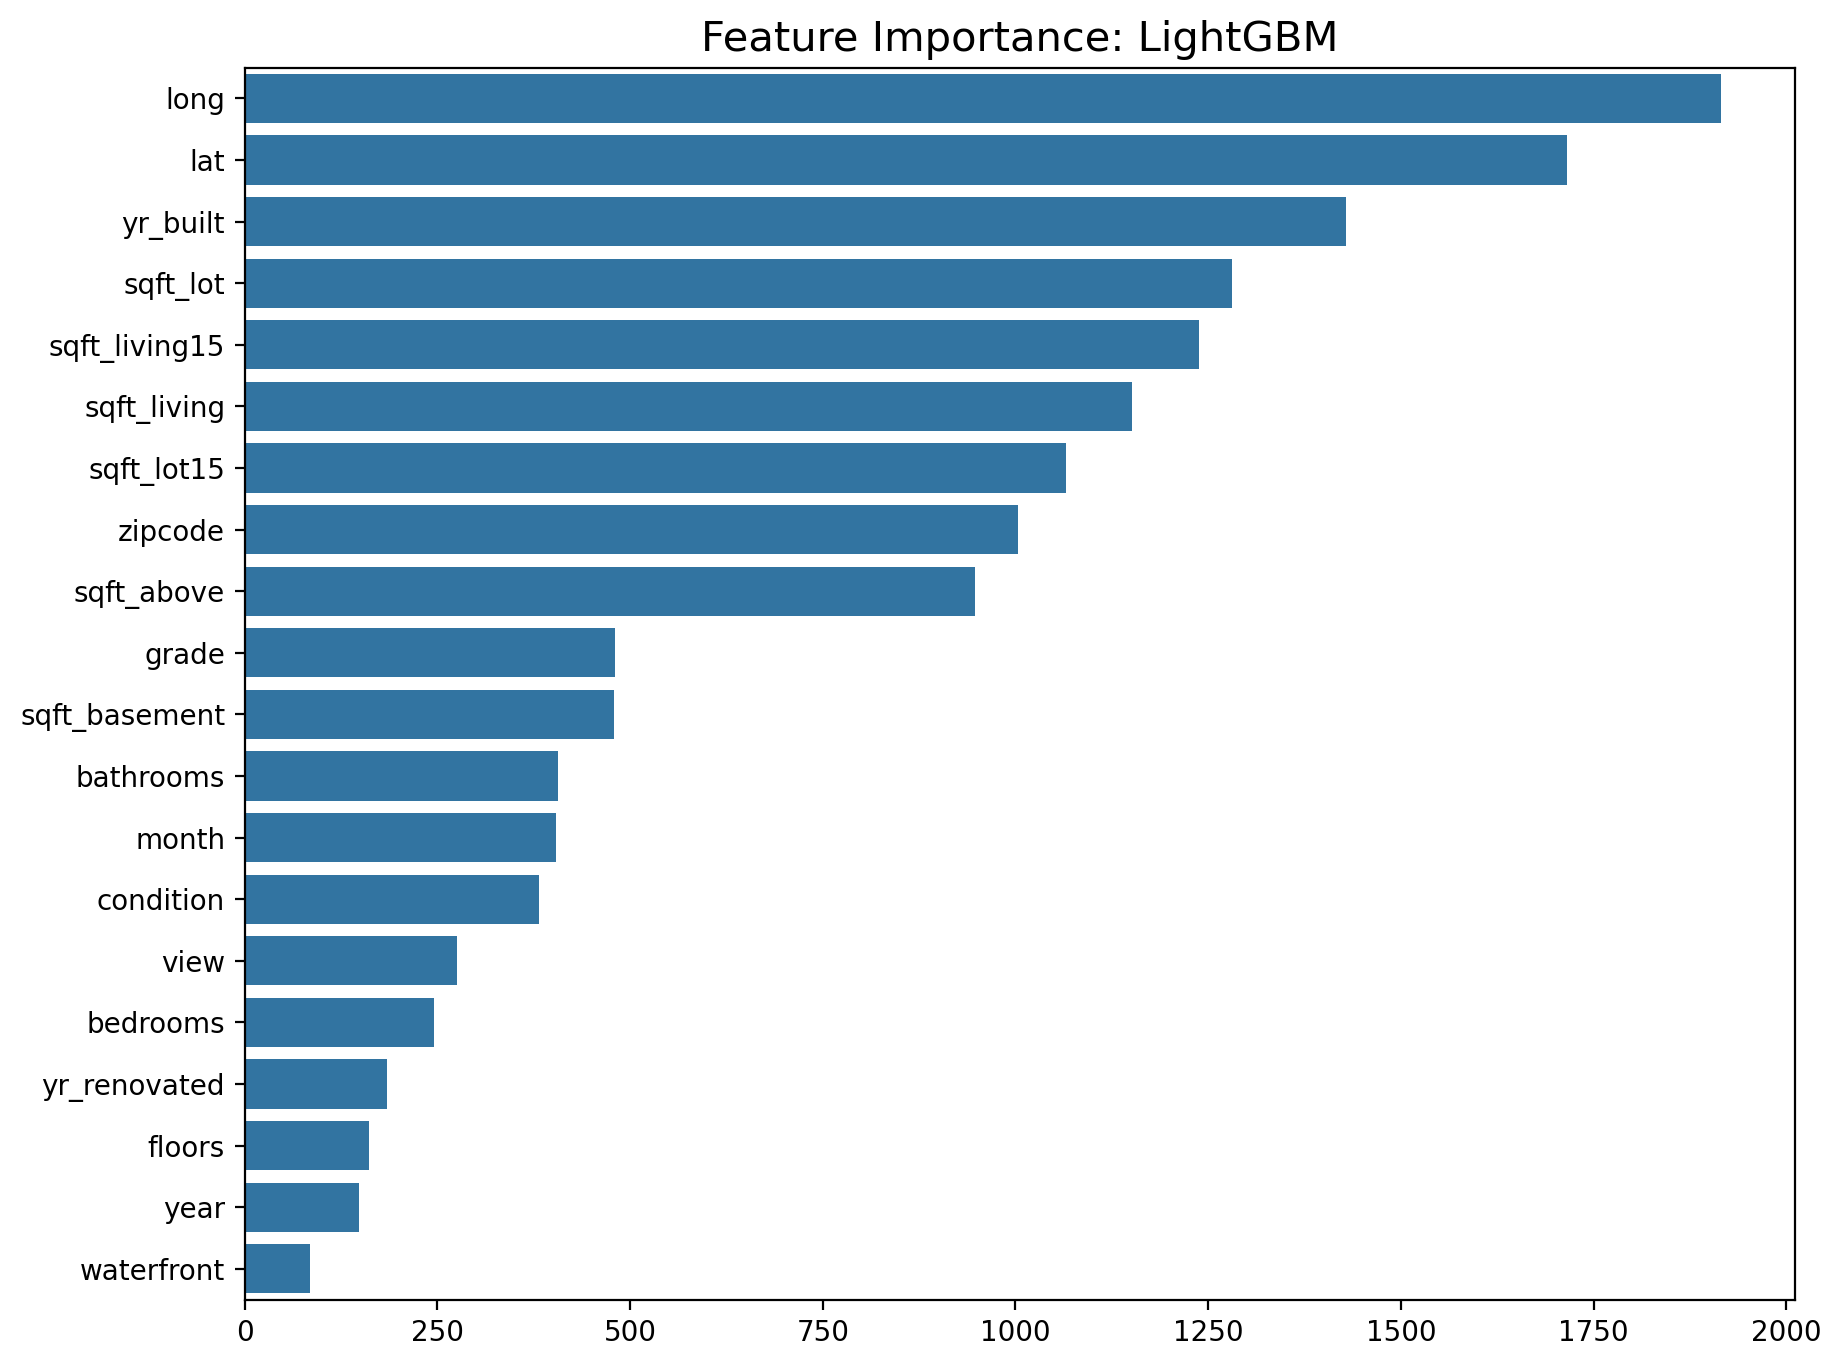

In [36]:
def plot_feature_importance(model, name, columns):
    # 모델에 내장된 중요도 가져오기
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances[indices], y=[columns[i] for i in indices])
    plt.title(f'Feature Importance: {name}', fontsize=15)
    plt.show()

# 1등 모델인 LightGBM의 중요도 확인
plot_feature_importance(models[2]['model'], 'LightGBM', x.columns)

회귀 모델의 경우에는 cross_val_score 함수가 R<sup>2</sup>를 반환합니다.<br>
R<sup>2</sup> 값이 1에 가까울수록 모델이 데이터를 잘 표현함을 나타냅니다. 3개 트리 모델이 상당히 훈련 데이터에 대해 괜찮은 성능을 보여주고 있습니다.<br> 훈련 데이터셋으로 3개 모델을 학습시키고, Average Blending을 통해 제출 결과를 만들겠습니다.

## 6. 앙상블 모델 만들고 제출하기

In [37]:
def AveragingBlending(models, x, y, sub_x):
    for m in models : 
        m['model'].fit(x.values, y)
    
    predictions = np.column_stack([
        m['model'].predict(sub_x.values) for m in models
    ])
    return np.mean(predictions, axis=1)

In [38]:
y_pred = AveragingBlending(models, x, y, sub)

In [39]:
# 타겟 값 로그 변환 복구
y_pred = np.expm1(y_pred)

In [40]:
sub = pd.DataFrame(data={'id':sub_id,'price':y_pred})

In [41]:
sub.to_csv('submission.csv', index=False)

In [42]:
import os
print(os.path.abspath('submission_tuned.csv'))

/home/jovyan/work/kaggle_kakr_housing/submission_tuned.csv
